# TSN Schedule Defragmentation Simulation (Per-Link Scheduling)

This notebook simulates TSN flow scheduling with **per-link time slot allocation**.

**Two Heuristics:**
1. **No-Reconfig**: Schedule new flows directly in fragmented schedule
2. **OF-FF (Oldest First, First Fit)**: Defragment schedule first, then schedule new flows

**Scenario:**
- Load network topology from scenario.json
- Each link (connection/edge) has its own schedule with time slots
- Flows must reserve slots on ALL links in their path
- Create initial flows, then remove some to create fragmentation
- 100 new flows arrive
- Compare SBR (Scheduling Blocking Rate) between both heuristics

In [82]:
# Import required libraries
import json
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from dataclasses import dataclass
from typing import List, Tuple, Optional
import random

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

In [83]:
# Load network scenario
with open('scenario.json', 'r') as f:
    scenario = json.load(f)

# Build NetworkX graph
G = nx.DiGraph()

# Add nodes
for node in scenario['nodes']:
    G.add_node(node['name'], type=node['type'])

# Add edges (each edge = connection/link with its own schedule)
for link in scenario['links']:
    src_node = link['source']['node']
    dst_node = link['destination']['node']
    G.add_edge(src_node, dst_node, 
               speed=link.get('speed', 1000), delay=link.get('delay', 0))
    # Add reverse edge for bidirectional links
    G.add_edge(dst_node, src_node,
               speed=link.get('speed', 1000), delay=link.get('delay', 0))

print(f"Network loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges (bidirectional)")
print(f"Hosts: {[n for n, d in G.nodes(data=True) if d['type'] == 'host']}")
print(f"Switches: {[n for n, d in G.nodes(data=True) if d['type'] == 'switch']}")
print(f"\nLinks (connections): {list(G.edges())[:10]}...")  # Show first 10

KeyError: 'source'

In [ ]:
# TSN Flow dataclass
@dataclass
class Flow:
    flow_id: int
    src: str
    dst: str
    path: List[str]
    duration: int  # Number of time slots
    start_slot: int = -1  # -1 means not scheduled
    age: int = 0  # Age for OF-FF prioritization
    
    def __repr__(self):
        return f"Flow{self.flow_id}({self.src}->{self.dst}, dur={self.duration}, start={self.start_slot})"

In [ ]:
# Per-Link Schedule Manager
class LinkSchedule:
    """Manages time slot allocation for a single link/connection"""
    def __init__(self, link_id: Tuple[str, str], total_slots=100):
        self.link_id = link_id  # (src_node, dst_node)
        self.total_slots = total_slots
        self.slots = [None] * total_slots  # None = free, flow_id = occupied
        
    def can_allocate(self, flow_id: int, start_slot: int, duration: int) -> bool:
        """Check if slots are available for allocation"""
        if start_slot + duration > self.total_slots:
            return False
        for i in range(start_slot, start_slot + duration):
            if self.slots[i] is not None:
                return False
        return True
    
    def allocate(self, flow_id: int, start_slot: int, duration: int):
        """Allocate slots for a flow"""
        for i in range(start_slot, start_slot + duration):
            self.slots[i] = flow_id
    
    def deallocate(self, flow_id: int):
        """Remove all slots allocated to a flow"""
        self.slots = [None if fid == flow_id else fid for fid in self.slots]
    
    def find_first_fit(self, duration: int) -> Optional[int]:
        """Find first available slot that can fit duration"""
        consecutive = 0
        start = 0
        for i in range(self.total_slots):
            if self.slots[i] is None:
                if consecutive == 0:
                    start = i
                consecutive += 1
                if consecutive >= duration:
                    return start
            else:
                consecutive = 0
        return None
    
    def get_fragmentation(self) -> int:
        """Count number of gaps"""
        gaps = 0
        in_gap = False
        for slot in self.slots:
            if slot is None:
                if not in_gap:
                    gaps += 1
                    in_gap = True
            else:
                in_gap = False
        return gaps
    
    def get_utilization(self) -> float:
        """Get slot utilization percentage"""
        used = sum(1 for s in self.slots if s is not None)
        return (used / self.total_slots) * 100
    
    def copy(self):
        """Create deep copy"""
        new_link = LinkSchedule(self.link_id, self.total_slots)
        new_link.slots = self.slots.copy()
        return new_link


# Network-Wide Schedule Manager
class NetworkScheduler:
    """Manages schedules for all links in the network"""
    def __init__(self, graph: nx.DiGraph, total_slots=100):
        self.graph = graph
        self.total_slots = total_slots
        # Create a schedule for each link
        self.link_schedules = {}
        for edge in graph.edges():
            self.link_schedules[edge] = LinkSchedule(edge, total_slots)
        self.flows = {}  # flow_id -> Flow
    
    def add_flow(self, flow: Flow, start_slot: int) -> bool:
        """Schedule flow on all links in its path"""
        # Get edges from path
        edges = [(flow.path[i], flow.path[i+1]) for i in range(len(flow.path)-1)]
        
        # Check if all links can accommodate the flow
        for edge in edges:
            if edge not in self.link_schedules:
                return False
            if not self.link_schedules[edge].can_allocate(flow.flow_id, start_slot, flow.duration):
                return False
        
        # Allocate on all links
        for edge in edges:
            self.link_schedules[edge].allocate(flow.flow_id, start_slot, flow.duration)
        
        flow.start_slot = start_slot
        self.flows[flow.flow_id] = flow
        return True
    
    def remove_flow(self, flow_id: int):
        """Remove flow from all links"""
        if flow_id not in self.flows:
            return
        flow = self.flows[flow_id]
        edges = [(flow.path[i], flow.path[i+1]) for i in range(len(flow.path)-1)]
        for edge in edges:
            if edge in self.link_schedules:
                self.link_schedules[edge].deallocate(flow_id)
        del self.flows[flow_id]
    
    def attempt_schedule(self, flow: Flow) -> bool:
        """Try to schedule flow using first-fit on all path links"""
        edges = [(flow.path[i], flow.path[i+1]) for i in range(len(flow.path)-1)]
        
        # Find first slot that works for ALL links in path
        for start_slot in range(self.total_slots):
            can_schedule = True
            for edge in edges:
                if edge not in self.link_schedules:
                    can_schedule = False
                    break
                if not self.link_schedules[edge].can_allocate(flow.flow_id, start_slot, flow.duration):
                    can_schedule = False
                    break
            
            if can_schedule:
                return self.add_flow(flow, start_slot)
        
        return False
    
    def get_total_fragmentation(self) -> int:
        """Sum of gaps across all links"""
        return sum(ls.get_fragmentation() for ls in self.link_schedules.values())
    
    def get_avg_utilization(self) -> float:
        """Average utilization across all links"""
        if not self.link_schedules:
            return 0.0
        return sum(ls.get_utilization() for ls in self.link_schedules.values()) / len(self.link_schedules)
    
    def copy(self):
        """Deep copy of network scheduler"""
        new_scheduler = NetworkScheduler(self.graph, self.total_slots)
        new_scheduler.link_schedules = {lid: ls.copy() for lid, ls in self.link_schedules.items()}
        new_scheduler.flows = {fid: Flow(**vars(f)) for fid, f in self.flows.items()}
        return new_scheduler
    
    def __repr__(self):
        return f"NetworkScheduler(flows={len(self.flows)}, links={len(self.link_schedules)}, avg_util={self.get_avg_utilization():.1f}%, total_gaps={self.get_total_fragmentation()})"

In [ ]:
# OF-FF (Oldest First, First Fit) Defragmentation for Network
def defragment_of_ff(scheduler: NetworkScheduler) -> NetworkScheduler:
    """
    Defragment network schedule using Oldest First, First Fit strategy:
    1. Sort flows by age (oldest first)
    2. Remove all flows from all links
    3. Re-add flows in order, using first-fit placement on all path links
    """
    # Create new empty scheduler
    new_scheduler = NetworkScheduler(scheduler.graph, scheduler.total_slots)
    
    # Sort flows by age (oldest first)
    sorted_flows = sorted(scheduler.flows.values(), key=lambda f: f.age, reverse=True)
    
    # Re-schedule each flow using first-fit
    for flow in sorted_flows:
        # Create new flow instance (reset start_slot)
        new_flow = Flow(
            flow_id=flow.flow_id,
            src=flow.src,
            dst=flow.dst,
            path=flow.path,
            duration=flow.duration,
            age=flow.age
        )
        new_scheduler.attempt_schedule(new_flow)
    
    return new_scheduler

## Step 1: Create Initial Schedule with Fragmentation

In [ ]:
# Get host nodes for generating flows
hosts = [n for n, d in G.nodes(data=True) if d['type'] == 'host']
print(f"Available hosts: {hosts}")

# Create network scheduler (100 time slots per link)
scheduler = NetworkScheduler(G, total_slots=100)
print(f"\n{scheduler}")

# Add initial flows
initial_flows = []
flow_id = 0

# Create 20 initial flows
for i in range(20):
    src, dst = np.random.choice(hosts, size=2, replace=False)
    try:
        path = nx.shortest_path(G, src, dst)
    except nx.NetworkXNoPath:
        continue
    
    duration = np.random.randint(5, 15)
    flow = Flow(flow_id=flow_id, src=src, dst=dst, path=path, duration=duration, age=20-i)
    
    if scheduler.attempt_schedule(flow):
        initial_flows.append(flow)
        flow_id += 1

print(f"\nInitial schedule: {scheduler}")
print(f"Successfully scheduled {len(initial_flows)} flows")
print(f"Per-link info:")
for link_id, link_sched in list(scheduler.link_schedules.items())[:5]:
    print(f"  {link_id}: {link_sched.get_utilization():.1f}% util, {link_sched.get_fragmentation()} gaps")

Available hosts: ['D', 'F']

Initial schedule: TSNSchedule(flows=20, util=40.0%, gaps=1)
Successfully scheduled 20 flows


In [ ]:
# Remove flows in the middle to create fragmentation
flows_to_remove = [f.flow_id for f in list(scheduler.flows.values())[5:15]]  # Remove 10 flows from middle

print(f"Removing {len(flows_to_remove)} flows to create fragmentation...")
for fid in flows_to_remove:
    scheduler.remove_flow(fid)

print(f"\nFragmented schedule: {scheduler}")
print(f"Remaining flows: {len(scheduler.flows)}")
print(f"Per-link info after removal:")
for link_id, link_sched in list(scheduler.link_schedules.items())[:5]:
    print(f"  {link_id}: {link_sched.get_utilization():.1f}% util, {link_sched.get_fragmentation()} gaps")

Removing 10 flows to create fragmentation...

Fragmented schedule: TSNSchedule(flows=10, util=23.2%, gaps=2)
Remaining flows: 10


## Step 2: Generate 100 Incoming Flows

In [ ]:
# Generate 100 new flows
incoming_flows = []

for i in range(100):
    src, dst = np.random.choice(hosts, size=2, replace=False)
    try:
        path = nx.shortest_path(G, src, dst)
    except nx.NetworkXNoPath:
        continue
    
    duration = np.random.randint(3, 12)
    flow = Flow(flow_id=flow_id, src=src, dst=dst, path=path, duration=duration, age=0)
    incoming_flows.append(flow)
    flow_id += 1

print(f"Generated {len(incoming_flows)} incoming flows")
print(f"Duration range: {min(f.duration for f in incoming_flows)}-{max(f.duration for f in incoming_flows)} slots")

Generated 100 incoming flows
Duration range: 5-24 slots


## Step 3: Heuristic 1 - No Reconfiguration

In [ ]:
# Try scheduling in fragmented schedule directly
scheduler_no_reconfig = scheduler.copy()
scheduled_no_reconfig = 0
blocked_no_reconfig = 0

for flow in incoming_flows:
    if scheduler_no_reconfig.attempt_schedule(flow):
        scheduled_no_reconfig += 1
    else:
        blocked_no_reconfig += 1

sbr_no_reconfig = (blocked_no_reconfig / len(incoming_flows)) * 100

print("=" * 60)
print("HEURISTIC 1: NO RECONFIGURATION")
print("=" * 60)
print(f"Scheduled: {scheduled_no_reconfig}/{len(incoming_flows)} flows")
print(f"Blocked: {blocked_no_reconfig}/{len(incoming_flows)} flows")
print(f"SBR (Scheduling Blocking Rate): {sbr_no_reconfig:.2f}%")
print(f"Final schedule: {scheduler_no_reconfig}")

HEURISTIC 1: NO RECONFIGURATION
Scheduled: 56/100 flows
Blocked: 44/100 flows
SBR (Scheduling Blocking Rate): 44.00%
Final schedule: TSNSchedule(flows=66, util=99.4%, gaps=2)


## Step 4: Heuristic 2 - OF-FF (Oldest First, First Fit)

In [ ]:
# Apply OF-FF defragmentation first
print("Applying OF-FF defragmentation...")
scheduler_of_ff = defragment_of_ff(scheduler)
print(f"After defragmentation: {scheduler_of_ff}")
print(f"Fragmentation reduced: {scheduler.get_total_fragmentation()} -> {scheduler_of_ff.get_total_fragmentation()} total gaps")

# Now try scheduling the new flows
scheduled_of_ff = 0
blocked_of_ff = 0

for flow in incoming_flows:
    if scheduler_of_ff.attempt_schedule(flow):
        scheduled_of_ff += 1
    else:
        blocked_of_ff += 1

sbr_of_ff = (blocked_of_ff / len(incoming_flows)) * 100

print("\n" + "=" * 60)
print("HEURISTIC 2: OF-FF (OLDEST FIRST, FIRST FIT)")
print("=" * 60)
print(f"Scheduled: {scheduled_of_ff}/{len(incoming_flows)} flows")
print(f"Blocked: {blocked_of_ff}/{len(incoming_flows)} flows")
print(f"SBR (Scheduling Blocking Rate): {sbr_of_ff:.2f}%")
print(f"Final schedule: {scheduler_of_ff}")

Applying OF-FF defragmentation...
After defragmentation: TSNSchedule(flows=10, util=23.2%, gaps=1)
Fragmentation reduced: 2 -> 1 gaps

HEURISTIC 2: OF-FF (OLDEST FIRST, FIRST FIT)
Scheduled: 57/100 flows
Blocked: 43/100 flows
SBR (Scheduling Blocking Rate): 43.00%
Final schedule: TSNSchedule(flows=67, util=100.0%, gaps=0)


## Step 5: Comparison and Results

In [ ]:
# Print comparison
print("\n" + "=" * 60)
print("COMPARISON SUMMARY")
print("=" * 60)
print(f"\nInitial fragmented schedule:")
print(f"  - Flows: {len(scheduler.flows)}")
print(f"  - Avg Utilization: {scheduler.get_avg_utilization():.2f}%")
print(f"  - Total Gaps: {scheduler.get_total_fragmentation()}")

print(f"\n{'Strategy':<20} {'Scheduled':<12} {'Blocked':<12} {'SBR':<12} {'Final Gaps':<12}")
print("-" * 68)
print(f"{'No Reconfig':<20} {scheduled_no_reconfig:<12} {blocked_no_reconfig:<12} {sbr_no_reconfig:<12.2f} {scheduler_no_reconfig.get_total_fragmentation():<12}")
print(f"{'OF-FF':<20} {scheduled_of_ff:<12} {blocked_of_ff:<12} {sbr_of_ff:<12.2f} {scheduler_of_ff.get_total_fragmentation():<12}")

improvement = scheduled_of_ff - scheduled_no_reconfig
improvement_pct = (improvement / len(incoming_flows)) * 100

print(f"\nImprovement with OF-FF: +{improvement} flows ({improvement_pct:+.2f}%)") 
print(f"SBR reduction: {sbr_no_reconfig - sbr_of_ff:.2f} percentage points")


COMPARISON SUMMARY

Initial fragmented schedule:
  - Flows: 10
  - Utilization: 23.20%
  - Gaps: 2

Strategy             Scheduled    Blocked      SBR          Final Gaps  
--------------------------------------------------------------------
No Reconfig          56           44           44.00        2           
OF-FF                57           43           43.00        0           

Improvement with OF-FF: +1 flows (+1.00%)
SBR reduction: 1.00 percentage points


## Visualizations

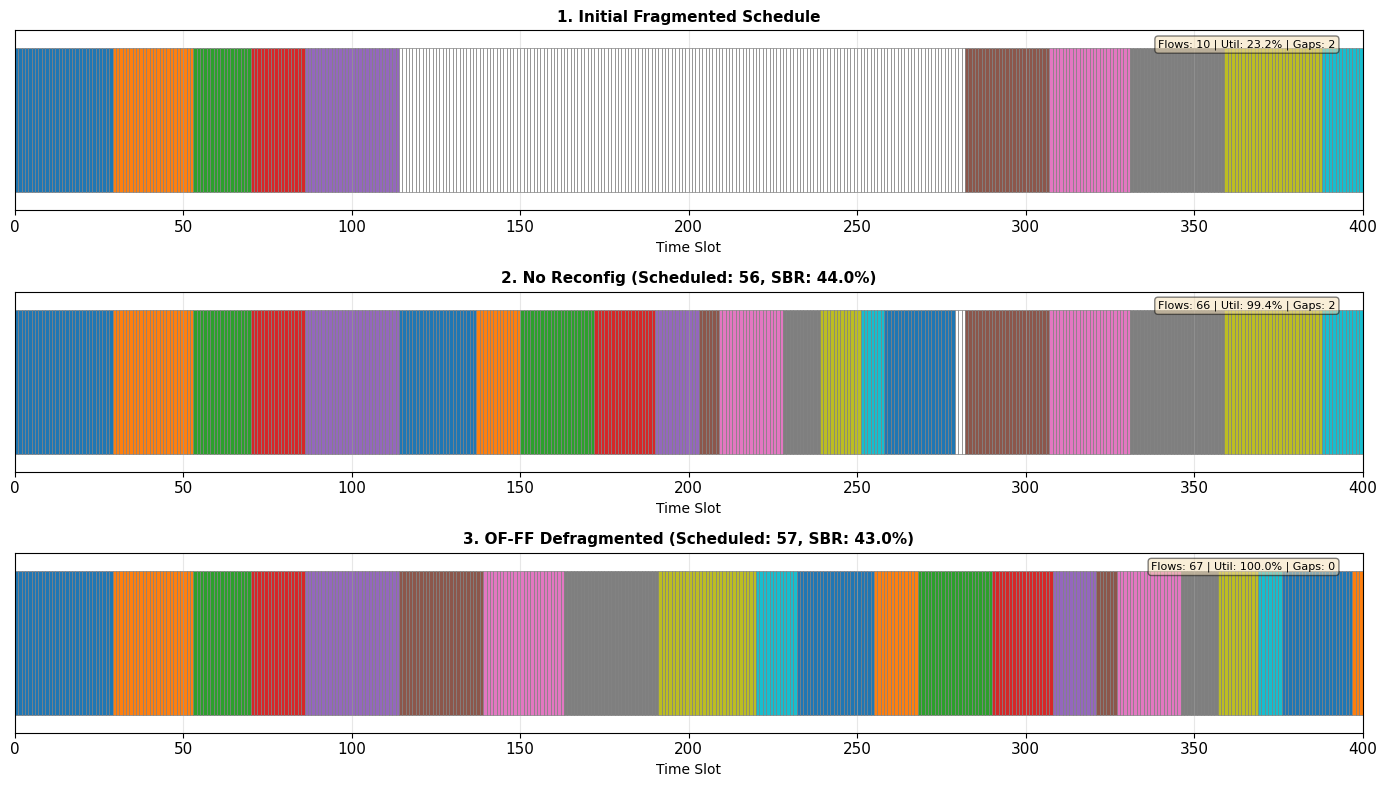

Saved: tsn_schedule_comparison.png


In [ ]:
# Visualization 1: Per-Link Schedule Comparison (like your image)
def visualize_per_link_schedules(scheduler, title, ax, max_links=8):
    """Visualize schedules for multiple links (like the image you showed)"""
    # Select most utilized links for visualization
    links_sorted = sorted(scheduler.link_schedules.items(), 
                         key=lambda x: x[1].get_utilization(), reverse=True)[:max_links]
    
    y_labels = []
    for idx, (link_id, link_sched) in enumerate(links_sorted):
        # Plot each link's schedule
        y_pos = len(links_sorted) - idx - 1
        y_labels.append(f"{link_id[0]}-{link_id[1]}")
        
        # Create colored bars for each flow
        for slot_idx, flow_id in enumerate(link_sched.slots):
            if flow_id is not None:
                color = f'C{flow_id % 10}'
                ax.barh(y_pos, 1, left=slot_idx, height=0.7, color=color, 
                       edgecolor='black', linewidth=0.5)
            else:
                # Free slot (white)
                ax.barh(y_pos, 1, left=slot_idx, height=0.7, color='white',
                       edgecolor='gray', linewidth=0.3, alpha=0.5)
    
    ax.set_yticks(range(len(links_sorted)))
    ax.set_yticklabels(y_labels[::-1], fontsize=9)
    ax.set_xlabel('Slot Number', fontsize=10, fontweight='bold')
    ax.set_ylabel('Link', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlim(0, scheduler.total_slots)
    ax.grid(axis='x', alpha=0.2)
    
    # Add stats
    stats = f"Flows: {len(scheduler.flows)} | Avg Util: {scheduler.get_avg_utilization():.1f}% | Total Gaps: {scheduler.get_total_fragmentation()}"
    ax.text(0.98, 0.02, stats, transform=ax.transAxes, fontsize=8, 
            ha='right', va='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# Create figure with 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(16, 10))

visualize_per_link_schedules(scheduler, "1. Initial Fragmented Schedule (Per-Link View)", axes[0])
visualize_per_link_schedules(scheduler_no_reconfig, 
                            f"2. No Reconfig (Scheduled: {scheduled_no_reconfig}/{len(incoming_flows)}, SBR: {sbr_no_reconfig:.1f}%)", 
                            axes[1])
visualize_per_link_schedules(scheduler_of_ff, 
                            f"3. OF-FF Defragmented (Scheduled: {scheduled_of_ff}/{len(incoming_flows)}, SBR: {sbr_of_ff:.1f}%)", 
                            axes[2])

plt.tight_layout()
plt.savefig('tsn_per_link_schedule_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: tsn_per_link_schedule_comparison.png")

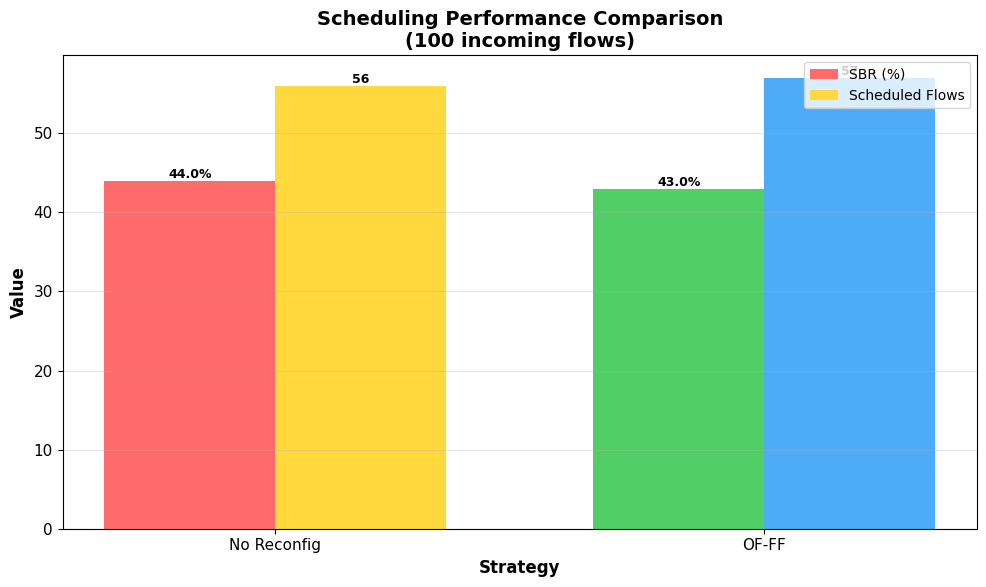

Saved: tsn_sbr_comparison.png


In [ ]:
# Visualization 2: SBR Comparison Bar Chart
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

strategies = ['No Reconfig', 'OF-FF']
sbr_values = [sbr_no_reconfig, sbr_of_ff]
scheduled_values = [scheduled_no_reconfig, scheduled_of_ff]

x = np.arange(len(strategies))
width = 0.35

bars1 = ax.bar(x - width/2, sbr_values, width, label='SBR (%)', color=['#ff6b6b', '#51cf66'])
bars2 = ax.bar(x + width/2, scheduled_values, width, label='Scheduled Flows', color=['#ffd93d', '#4dabf7'])

ax.set_xlabel('Strategy', fontsize=12, fontweight='bold')
ax.set_ylabel('Value', fontsize=12, fontweight='bold')
ax.set_title(f'Scheduling Performance Comparison\n({len(incoming_flows)} incoming flows)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(strategies)
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('tsn_sbr_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: tsn_sbr_comparison.png")

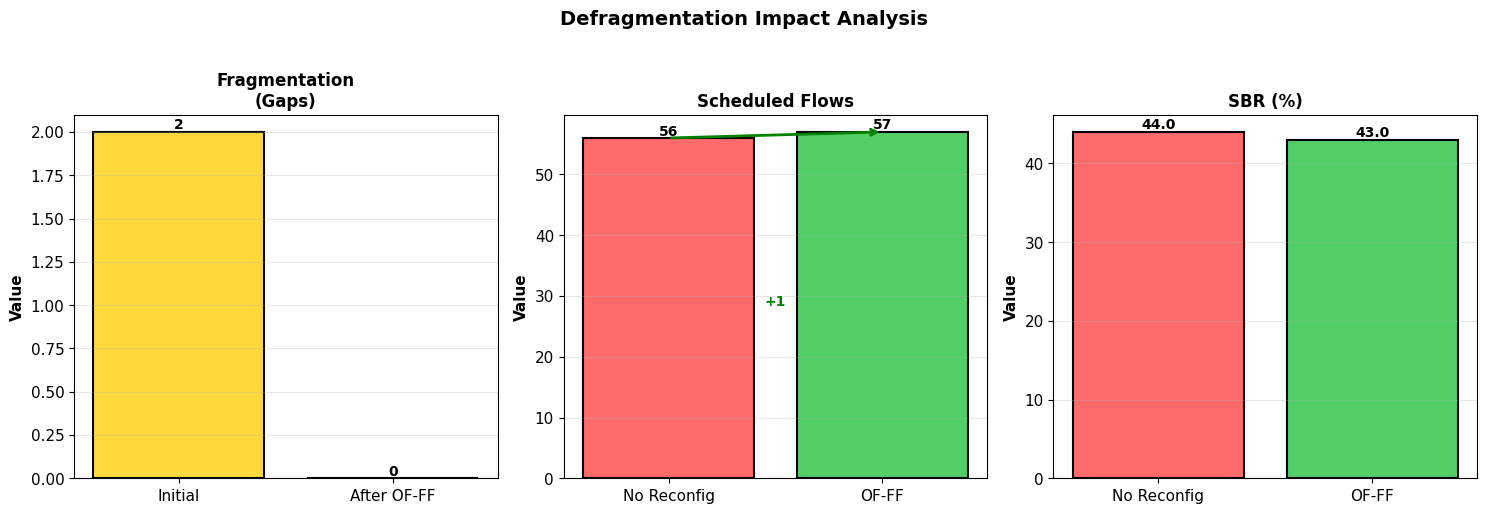

Saved: tsn_metrics_comparison.png


In [ ]:
# Visualization 3: Detailed metrics comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [
    ('Total Fragmentation\n(Gaps)', [scheduler.get_total_fragmentation(), scheduler_of_ff.get_total_fragmentation()], ['Initial', 'After OF-FF']),
    ('Scheduled Flows', [scheduled_no_reconfig, scheduled_of_ff], ['No Reconfig', 'OF-FF']),
    ('SBR (%)', [sbr_no_reconfig, sbr_of_ff], ['No Reconfig', 'OF-FF'])
]

for idx, (metric_name, values, labels) in enumerate(metrics):
    ax = axes[idx]
    colors = ['#ff6b6b', '#51cf66'] if idx != 0 else ['#ffd93d', '#4dabf7']
    bars = ax.bar(labels, values, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Value', fontsize=11, fontweight='bold')
    ax.set_title(metric_name, fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}' if idx == 2 else f'{int(height)}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Add improvement arrow for metrics 1 and 2
    if idx > 0:
        improvement = values[1] - values[0]
        if improvement > 0:
            ax.annotate('', xy=(1, values[1]), xytext=(0, values[0]),
                       arrowprops=dict(arrowstyle='->', color='green', lw=2))
            ax.text(0.5, max(values) * 0.5, f'+{improvement:.1f}' if idx == 2 else f'+{int(improvement)}',
                   ha='center', fontsize=10, color='green', fontweight='bold')

plt.suptitle('Defragmentation Impact Analysis (Per-Link Scheduling)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('tsn_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: tsn_metrics_comparison.png")